In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, accuracy_score

# Load dataset
df = pd.read_csv('Online Purchase.csv')

# Initial exploration
print(df.head())

   Customer_ID  Gender  Age  Salary  Purchased
0            1    Male   35     500          0
1            2  Female   25  300000          1
2            3  Female  100  200000          0
3     15566689  Female   35   57000          0
4     15569641  Female   58   95000          1


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  403 non-null    int64 
 1   Gender       403 non-null    object
 2   Age          403 non-null    int64 
 3   Salary       403 non-null    int64 
 4   Purchased    403 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.9+ KB
None


In [3]:
print(df.describe(include='all'))

         Customer_ID  Gender         Age         Salary   Purchased
count   4.030000e+02     403  403.000000     403.000000  403.000000
unique           NaN       2         NaN            NaN         NaN
top              NaN  Female         NaN            NaN         NaN
freq             NaN     206         NaN            NaN         NaN
mean    1.557473e+07     NaN   37.771712   70465.260546    0.357320
std     1.352373e+06     NaN   10.915209   36598.127268    0.479806
min     1.000000e+00     NaN   18.000000     500.000000    0.000000
25%     1.562463e+07     NaN   29.500000   43000.000000    0.000000
50%     1.569326e+07     NaN   37.000000   70000.000000    0.000000
75%     1.575020e+07     NaN   46.000000   88000.000000    1.000000
max     1.581524e+07     NaN  100.000000  300000.000000    1.000000


In [5]:
print(df.isnull().sum())

Customer_ID    0
Gender         0
Age            0
Salary         0
Purchased      0
dtype: int64


In [13]:
# Drop remaining missing values if any
df.dropna(inplace=True)
print(df)

     Customer_ID  Gender  Age  Salary  Purchase_Made
0              1    Male   35     500              0
1              2  Female   25  300000              1
2              3  Female  100  200000              0
3       15566689  Female   35   57000              0
4       15569641  Female   58   95000              1
..           ...     ...  ...     ...            ...
398     15813113    Male   40  107000              1
399     15814004    Male   27   20000              0
400     15814553    Male   57   60000              1
401     15814816    Male   31   66000              0
402     15815236  Female   45  131000              1

[403 rows x 5 columns]


In [11]:

# Rename columns for clarity
df.rename(columns={'Purchased': 'Purchase_Made'}, inplace=True)
print(df)

     Customer_ID  Gender  Age  Salary  Purchase_Made
0              1    Male   35     500              0
1              2  Female   25  300000              1
2              3  Female  100  200000              0
3       15566689  Female   35   57000              0
4       15569641  Female   58   95000              1
..           ...     ...  ...     ...            ...
398     15813113    Male   40  107000              1
399     15814004    Male   27   20000              0
400     15814553    Male   57   60000              1
401     15814816    Male   31   66000              0
402     15815236  Female   45  131000              1

[403 rows x 5 columns]


In [20]:
# Check columns
print(df.columns)


Index(['Customer_ID', 'Age', 'Salary', 'Purchase_Made', 'Gender_Encoded',
       'Gender_Female', 'Gender_Male'],
      dtype='object')


In [21]:
# Encode categorical variables 
df['Gender_Encoded'] = df['Customer_ID'].map({'Male': 1, 'Female': 0})
df = pd.get_dummies(df, columns=['Customer_ID'])
print(df)

     Age  Salary  Purchase_Made  Gender_Encoded  Gender_Female  Gender_Male  \
0     35     500              0             NaN          False         True   
1     25  300000              1             NaN           True        False   
2    100  200000              0             NaN           True        False   
3     35   57000              0             NaN           True        False   
4     58   95000              1             NaN           True        False   
..   ...     ...            ...             ...            ...          ...   
398   40  107000              1             NaN          False         True   
399   27   20000              0             NaN          False         True   
400   57   60000              1             NaN          False         True   
401   31   66000              0             NaN          False         True   
402   45  131000              1             NaN           True        False   

     Customer_ID_1  Customer_ID_2  Customer_ID_3  C

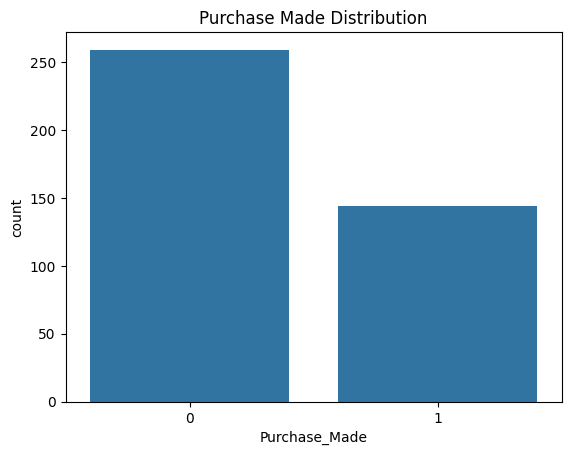

In [32]:
# Select features and target variable
features = ['Age', 'Salary', 'Gender_Encoded']
X = df[features]
y = df['Purchase_Made']

# Visualize class distribution
sns.countplot(x=y)
plt.title('Purchase Made Distribution')
plt.show()


In [6]:
# Check columns
print(df.columns)


Index(['Customer_ID', 'Gender', 'Age', 'Salary', 'Purchased'], dtype='object')


In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Check existing columns
print(df.columns)

# Encode 'Gender' if not already encoded
if 'Gender_Encoded' not in df.columns:
    le = LabelEncoder()
    df['Gender_Encoded'] = le.fit_transform(df['Gender'])

Index(['Customer_ID', 'Gender', 'Age', 'Salary', 'Purchased',
       'Gender_Encoded'],
      dtype='object')


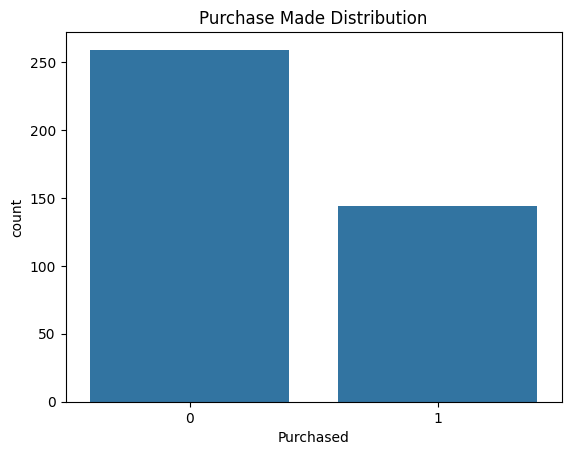

In [15]:
# Select features and target
features = ['Age', 'Salary', 'Gender_Encoded']
X = df[features]
y = df['Purchased']

# Visualize class distribution
sns.countplot(x=y)
plt.title('Purchase Made Distribution')
plt.show()

In [31]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy * 100:.2f}%")


Confusion Matrix:
[[45  3]
 [ 8 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        48
           1       0.89      0.76      0.82        33

    accuracy                           0.86        81
   macro avg       0.87      0.85      0.86        81
weighted avg       0.87      0.86      0.86        81


Accuracy Score: 86.42%


C:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


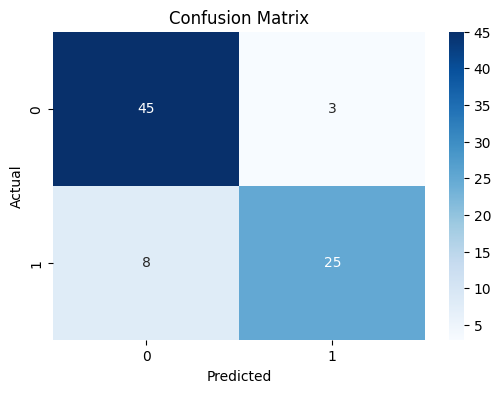

In [18]:
# Visualization: Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


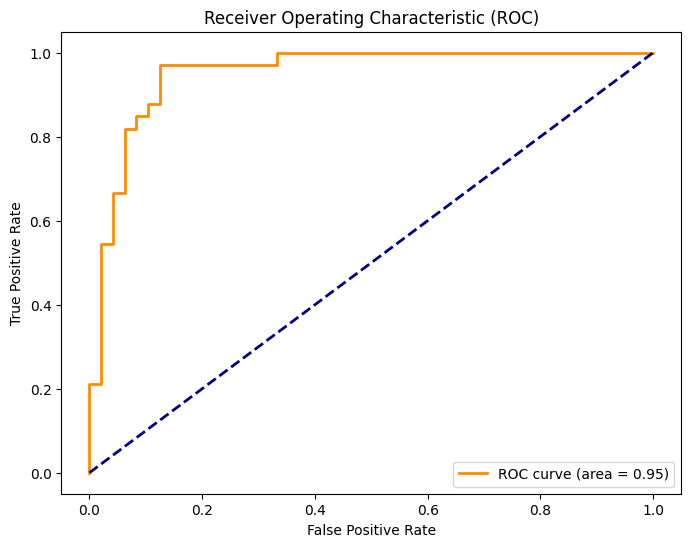

In [19]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()